In [48]:
#Installing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
#Reading csv file
df = pd.read_csv("Cleaned_data/Crash_Report_Cleaned.csv", low_memory= False)


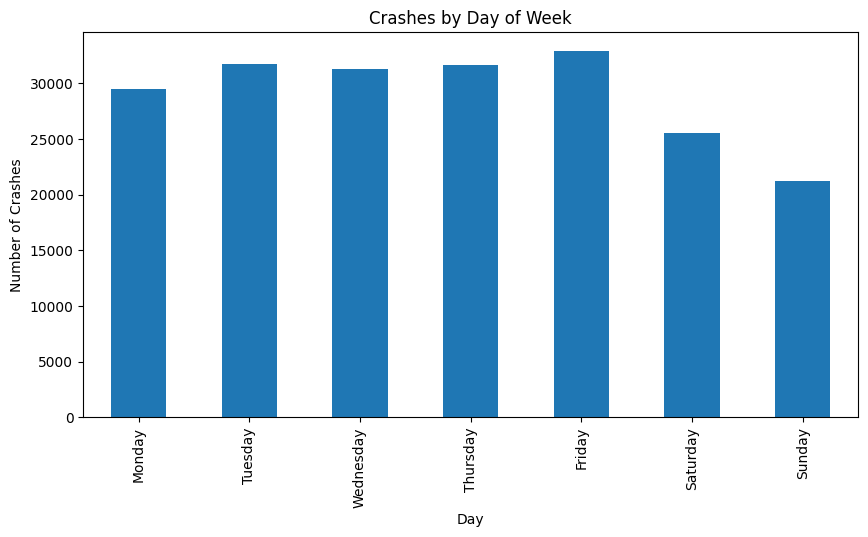

In [50]:
# Visualizing Crashes by Day of Week
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

plt.figure(figsize=(10,5))
df["Crash Day"].value_counts().reindex(order).plot(kind="bar")
plt.title("Crashes by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Crashes")
plt.show()


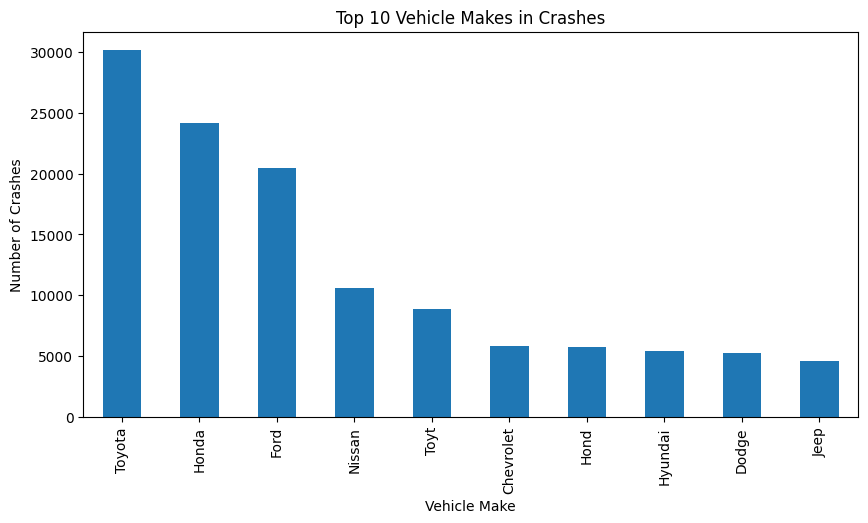

In [51]:
# Visualizing Top 10 Vehicle Makes in Crashes
top_makes = df["Vehicle Make"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_makes.plot(kind="bar")
plt.title("Top 10 Vehicle Makes in Crashes")
plt.xlabel("Vehicle Make")
plt.ylabel("Number of Crashes")
plt.show()

In [69]:
# Convert Vehicle Year to numeric
df["Vehicle Year"] = pd.to_numeric(df["Vehicle Year"], errors="coerce")

# Remove unrealistic years
df = df[(df["Vehicle Year"] >= 1980) & (df["Vehicle Year"] <= 2024)]

# Recalculate Vehicle Age
df["Vehicle Age"] = 2024 - df["Vehicle Year"]


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8028\2679111746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Vehicle Year"] = pd.to_numeric(df["Vehicle Year"], errors="coerce")


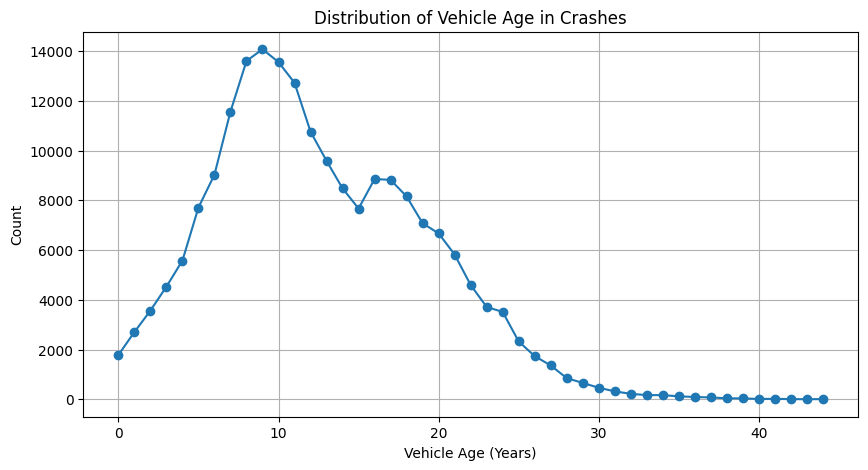

In [68]:
# Visualizing Distribution of Vehicle age in crashes
age_counts = df["Vehicle Age"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(age_counts.index, age_counts.values, marker='o')
plt.title("Distribution of Vehicle Age in Crashes")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

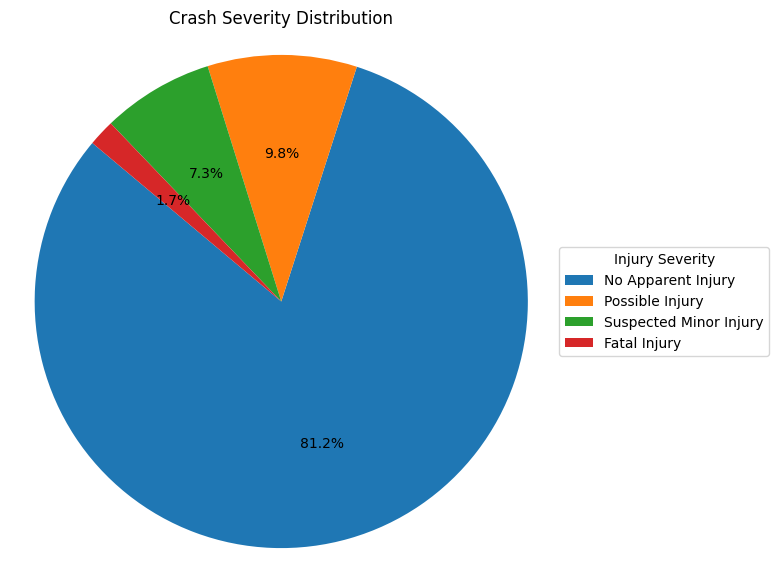

In [56]:
# Visualizing Crash Severity Distribution
severity_counts = df["Injury Severity"].value_counts()
threshold = 5000  
df["Injury_Severity_Grouped"] = df["Injury Severity"].apply(
    lambda x: x if severity_counts[x] >= threshold else "Fatal Injury"
)
grouped_counts = df["Injury_Severity_Grouped"].value_counts()
labels = grouped_counts.index
sizes = grouped_counts.values


fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    sizes,
    autopct="%1.1f%%",
    startangle=140
)

ax.legend(
    wedges,
    labels,
    title="Injury Severity",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

ax.set_title("Crash Severity Distribution")
ax.axis("equal")

plt.show()